# 101. チャンキング戦略の検証: データ準備とベースライン

## 目的
テキストのチャンキング方法が Embedding 検索精度に与える影響を検証するためのデータを準備し、
ベースライン（先頭500文字打ち切り）の Recall@K を計測する。

## 対象モデル
| モデル | HF ID | 次元 | prefix |
|--------|--------|------|--------|
| multilingual-e5-base | `intfloat/multilingual-e5-base` | 768 | `passage: ` / `query: ` |
| Qwen3-Embedding-0.6B | `Qwen/Qwen3-Embedding-0.6B` | 1024 | なし |

## 評価方法
- 実験93と同じ記事構造ベースの Recall@K（同一記事チャンク = 正解）
- 主指標: Recall@10, MRR, ADS (AUC-ROC)
- 副指標: IIG (Intra-Inter Gap)

In [1]:
import gc
import os
import pickle
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm

sys.path.insert(0, "../src")

# --- 定数 ---
N_ARTICLES = 1000       # 言語あたりの記事数
MIN_CHAR_LEN = 500      # 記事の最低文字数
SEED = 42
DATA_DIR = "../data"
os.makedirs(DATA_DIR, exist_ok=True)

def clear_gpu():
    """GPU メモリを解放"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

print("Setup complete.")

Setup complete.


## 1. Wikipedia 記事の収集（全文保持）

`wikimedia/wikipedia` 20231101 から JA/EN 各1,000件を収集。
500文字未満の記事はスキップ。全文を保持し、打ち切りは行わない。

In [2]:
def collect_full_articles(lang_code: str, n_articles: int = N_ARTICLES,
                          min_char_len: int = MIN_CHAR_LEN) -> list[dict]:
    """Wikipedia記事を全文で収集する。

    Returns:
        list of dict with keys: article_id, title, text, paragraphs
    """
    wiki = load_dataset(
        "wikimedia/wikipedia",
        f"20231101.{lang_code}",
        split="train",
        streaming=True,
    )

    articles = []
    for item in tqdm(wiki, total=n_articles * 3, desc=f"Wikipedia {lang_code}"):
        if len(articles) >= n_articles:
            break

        text = item["text"].strip()
        if len(text) < min_char_len:
            continue

        # 段落分割（空行区切り）
        paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]

        articles.append({
            "article_id": len(articles),
            "title": item.get("title", f"article_{len(articles)}"),
            "text": text,
            "paragraphs": paragraphs,
        })

    return articles


articles_ja = collect_full_articles("ja")
articles_en = collect_full_articles("en")
print(f"JA: {len(articles_ja)} articles, EN: {len(articles_en)} articles")

Wikipedia ja:   0%|          | 0/3000 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Wikipedia en:   0%|          | 0/3000 [00:00<?, ?it/s]

JA: 1000 articles, EN: 1000 articles


In [3]:
# データ保存
with open(os.path.join(DATA_DIR, "101_articles_ja.pkl"), "wb") as f:
    pickle.dump(articles_ja, f)
with open(os.path.join(DATA_DIR, "101_articles_en.pkl"), "wb") as f:
    pickle.dump(articles_en, f)
print("Saved articles to pkl files.")

Saved articles to pkl files.


## 2. 記事統計

文字数分布、トークン数分布（両モデルのtokenizer）、段落数の統計を確認する。

In [4]:
from transformers import AutoTokenizer

tokenizer_e5 = AutoTokenizer.from_pretrained("intfloat/multilingual-e5-base")
tokenizer_qwen = AutoTokenizer.from_pretrained("Qwen/Qwen3-Embedding-0.6B")

def article_stats(articles: list[dict], tokenizer_e5, tokenizer_qwen) -> pd.DataFrame:
    """記事ごとの統計量を計算"""
    rows = []
    for art in articles:
        text = art["text"]
        n_chars = len(text)
        n_tokens_e5 = len(tokenizer_e5.encode(text, add_special_tokens=False))
        n_tokens_qwen = len(tokenizer_qwen.encode(text, add_special_tokens=False))
        n_paragraphs = len(art["paragraphs"])
        rows.append({
            "article_id": art["article_id"],
            "n_chars": n_chars,
            "n_tokens_e5": n_tokens_e5,
            "n_tokens_qwen": n_tokens_qwen,
            "n_paragraphs": n_paragraphs,
        })
    return pd.DataFrame(rows)

stats_ja = article_stats(articles_ja, tokenizer_e5, tokenizer_qwen)
stats_en = article_stats(articles_en, tokenizer_e5, tokenizer_qwen)

for lang, stats in [("JA", stats_ja), ("EN", stats_en)]:
    print(f"\n=== {lang} ===")
    print(stats[["n_chars", "n_tokens_e5", "n_tokens_qwen", "n_paragraphs"]].describe().round(1))

Token indices sequence length is longer than the specified maximum sequence length for this model (1572 > 512). Running this sequence through the model will result in indexing errors



=== JA ===
       n_chars  n_tokens_e5  n_tokens_qwen  n_paragraphs
count   1000.0       1000.0         1000.0        1000.0
mean    9000.7       5510.1         6595.3          48.3
std    10635.7       6677.1         7898.2          53.4
min      509.0        235.0          270.0           4.0
25%     1968.0       1217.0         1455.8          14.0
50%     4837.5       3027.5         3564.0          28.0
75%    12030.2       7350.5         8909.5          61.0
max    96325.0      60035.0        67831.0         414.0

=== EN ===
        n_chars  n_tokens_e5  n_tokens_qwen  n_paragraphs
count    1000.0       1000.0         1000.0        1000.0
mean    23368.3       5664.9         5449.9          54.1
std     21757.6       5179.1         4896.0          47.0
min       508.0        117.0          109.0           2.0
25%      6876.0       1716.5         1628.8          18.0
50%     17312.5       4276.0         3948.5          39.0
75%     32593.2       7911.5         8206.2          76.2

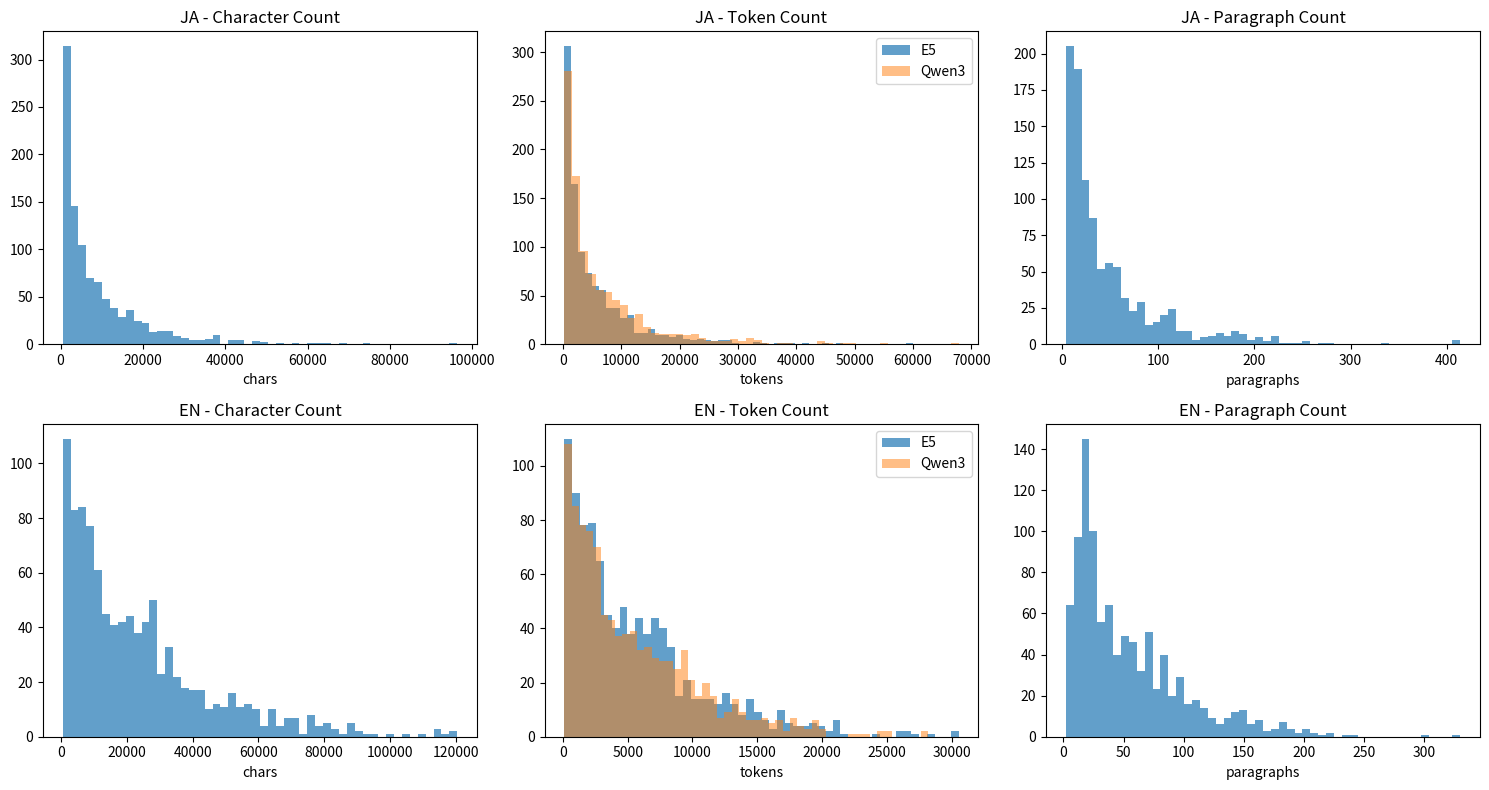

In [5]:
# 分布の可視化
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, (lang, stats) in enumerate([("JA", stats_ja), ("EN", stats_en)]):
    axes[row, 0].hist(stats["n_chars"], bins=50, alpha=0.7)
    axes[row, 0].set_title(f"{lang} - Character Count")
    axes[row, 0].set_xlabel("chars")

    axes[row, 1].hist(stats["n_tokens_e5"], bins=50, alpha=0.7, label="E5")
    axes[row, 1].hist(stats["n_tokens_qwen"], bins=50, alpha=0.5, label="Qwen3")
    axes[row, 1].set_title(f"{lang} - Token Count")
    axes[row, 1].set_xlabel("tokens")
    axes[row, 1].legend()

    axes[row, 2].hist(stats["n_paragraphs"], bins=50, alpha=0.7)
    axes[row, 2].set_title(f"{lang} - Paragraph Count")
    axes[row, 2].set_xlabel("paragraphs")

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "101_article_stats.png"), dpi=100, bbox_inches="tight")
plt.show()

## 3. チャンキングユーティリティ関数

後続の102/103で使用する3種類のチャンキング関数を定義する。

In [6]:
def chunk_fixed_token(text: str, tokenizer, size: int, overlap: int = 0) -> list[str]:
    """トークン固定長でチャンク分割する。

    Args:
        text: 入力テキスト
        tokenizer: HuggingFace tokenizer
        size: チャンクサイズ（トークン数）
        overlap: オーバーラップ（トークン数）

    Returns:
        チャンクのリスト（デコード済みテキスト）
    """
    token_ids = tokenizer.encode(text, add_special_tokens=False)
    if len(token_ids) == 0:
        return []

    step = max(1, size - overlap)
    chunks = []
    for start in range(0, len(token_ids), step):
        chunk_ids = token_ids[start : start + size]
        chunk_text = tokenizer.decode(chunk_ids, skip_special_tokens=True).strip()
        if chunk_text:
            chunks.append(chunk_text)
        if start + size >= len(token_ids):
            break
    return chunks


def chunk_by_sentence(text: str, tokenizer, max_tokens: int,
                      overlap_sentences: int = 0, lang: str = "ja") -> list[str]:
    """文境界でチャンク分割する。

    Args:
        text: 入力テキスト
        tokenizer: HuggingFace tokenizer
        max_tokens: チャンクの最大トークン数
        overlap_sentences: 次チャンクに引き継ぐ文の数
        lang: "ja" or "en"

    Returns:
        チャンクのリスト
    """
    # 文分割
    if lang == "ja":
        sentences = re.split(r"(?<=[。！？\n])", text)
    else:
        sentences = re.split(r"(?<=[.!?\n])\s+", text)
    sentences = [s.strip() for s in sentences if s.strip()]

    if not sentences:
        return []

    chunks = []
    current_sents = []
    current_tokens = 0

    for sent in sentences:
        sent_tokens = len(tokenizer.encode(sent, add_special_tokens=False))
        if current_tokens + sent_tokens > max_tokens and current_sents:
            chunks.append("".join(current_sents) if lang == "ja" else " ".join(current_sents))
            # オーバーラップ: 末尾N文を引き継ぐ
            if overlap_sentences > 0 and len(current_sents) > overlap_sentences:
                carry = current_sents[-overlap_sentences:]
                current_sents = carry
                current_tokens = sum(
                    len(tokenizer.encode(s, add_special_tokens=False)) for s in carry
                )
            else:
                current_sents = []
                current_tokens = 0

        current_sents.append(sent)
        current_tokens += sent_tokens

    if current_sents:
        chunks.append("".join(current_sents) if lang == "ja" else " ".join(current_sents))

    return chunks


def chunk_by_paragraph(text: str, tokenizer, max_tokens: int) -> list[str]:
    """段落ベースでチャンク分割する。短い段落はマージ、長い段落は文境界で分割。

    Args:
        text: 入力テキスト
        tokenizer: HuggingFace tokenizer
        max_tokens: チャンクの最大トークン数

    Returns:
        チャンクのリスト
    """
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    if not paragraphs:
        return []

    chunks = []
    current_paras = []
    current_tokens = 0

    for para in paragraphs:
        para_tokens = len(tokenizer.encode(para, add_special_tokens=False))

        # 段落単体でmax_tokensを超える場合は文分割
        if para_tokens > max_tokens:
            if current_paras:
                chunks.append("\n\n".join(current_paras))
                current_paras = []
                current_tokens = 0
            # 長い段落を文で分割
            sub_chunks = chunk_by_sentence(para, tokenizer, max_tokens, lang="ja")
            chunks.extend(sub_chunks)
            continue

        if current_tokens + para_tokens > max_tokens and current_paras:
            chunks.append("\n\n".join(current_paras))
            current_paras = []
            current_tokens = 0

        current_paras.append(para)
        current_tokens += para_tokens

    if current_paras:
        chunks.append("\n\n".join(current_paras))

    return chunks


# テスト
sample_text = articles_ja[0]["text"]
print(f"Original: {len(sample_text)} chars")
for name, fn in [
    ("fixed_256", lambda t: chunk_fixed_token(t, tokenizer_e5, 256, 64)),
    ("sentence_256", lambda t: chunk_by_sentence(t, tokenizer_e5, 256, 1, "ja")),
    ("paragraph_256", lambda t: chunk_by_paragraph(t, tokenizer_e5, 256)),
]:
    chunks = fn(sample_text)
    print(f"  {name}: {len(chunks)} chunks, avg {np.mean([len(c) for c in chunks]):.0f} chars")

Original: 2707 chars
  fixed_256: 8 chunks, avg 439 chars
  sentence_256: 8 chunks, avg 355 chars
  paragraph_256: 9 chunks, avg 299 chars


## 4. 評価指標の定義

- **Recall@K**: クエリチャンクに対し、cosine類似度Top-Kに同一記事の他チャンクが含まれる割合
- **MRR**: 同一記事の最初のヒットの逆順位の平均
- **ADS (AUC-ROC)**: 同一記事ペア vs 異記事ペアの識別力

In [7]:
def compute_retrieval_metrics(embeddings: np.ndarray, article_ids: np.ndarray,
                              k: int = 10, n_queries: int = 1000) -> dict:
    """コサイン類似度ベースの Recall@K, MRR を計算する。

    各クエリチャンクについて、同一記事の他チャンクが Top-K に含まれるかを評価。

    Args:
        embeddings: (N, D) L2正規化済み
        article_ids: (N,) 各チャンクの記事ID
        k: Top-K
        n_queries: 評価するクエリ数

    Returns:
        dict with Recall@K, MRR
    """
    n = len(embeddings)
    rng = np.random.default_rng(SEED)
    query_ids = rng.choice(n, min(n_queries, n), replace=False)

    recalls = []
    mrrs = []

    for qid in query_ids:
        # 同一記事の他チャンク（正解集合）
        same_art = np.where((article_ids == article_ids[qid]) & (np.arange(n) != qid))[0]
        if len(same_art) == 0:
            continue

        # コサイン類似度（正規化済みなので内積）
        sims = embeddings[qid] @ embeddings.T
        sims[qid] = -2.0  # 自分自身を除外
        topk_ids = np.argsort(sims)[-k:][::-1]

        # Recall@K: 正解のうち Top-K に含まれる割合
        found = len(set(same_art) & set(topk_ids))
        recalls.append(found / min(len(same_art), k))

        # MRR: Top-K内で最初に正解が出る順位の逆数
        rr = 0.0
        for rank, idx in enumerate(topk_ids, 1):
            if idx in same_art:
                rr = 1.0 / rank
                break
        mrrs.append(rr)

    return {
        f"Recall@{k}": float(np.mean(recalls)),
        "MRR": float(np.mean(mrrs)),
        "n_queries": len(recalls),
    }


def compute_ads(embeddings: np.ndarray, article_ids: np.ndarray,
                n_sample_pairs: int = 50000) -> dict:
    """ADS (Article Discrimination Score) = AUC-ROC と IIG を計算する。"""
    n = len(embeddings)
    rng = np.random.default_rng(SEED)

    idx1 = rng.choice(n, n_sample_pairs, replace=True)
    idx2 = rng.choice(n, n_sample_pairs, replace=True)
    mask = idx1 != idx2
    idx1, idx2 = idx1[mask], idx2[mask]

    cos_sims = np.sum(embeddings[idx1] * embeddings[idx2], axis=1)
    same_article = (article_ids[idx1] == article_ids[idx2]).astype(int)

    ads = roc_auc_score(same_article, cos_sims)

    intra_mask = same_article == 1
    inter_mask = same_article == 0
    intra_mean = float(np.mean(cos_sims[intra_mask])) if intra_mask.sum() > 0 else 0.0
    inter_mean = float(np.mean(cos_sims[inter_mask])) if inter_mask.sum() > 0 else 0.0

    return {
        "ADS (AUC)": ads,
        "IIG": intra_mean - inter_mean,
        "intra_cos": intra_mean,
        "inter_cos": inter_mean,
    }

print("Evaluation functions ready.")

Evaluation functions ready.


## 5. ベースライン: 先頭500文字打ち切り

実験93と同条件（先頭500文字で打ち切り、段落分割なし）でベースラインを作成する。
各記事から複数段落（80文字以上、最大5段落、各500文字以内）を抽出し、
段落単位の embedding で Recall@10 を計測。

In [8]:
# 実験93と同条件のベースライン: 段落分割 → 80文字以上、最大5段落、各500文字以内
MIN_PARA_LEN = 80
MAX_PARA_LEN = 500
MAX_PARAGRAPHS = 5
MIN_PARAGRAPHS = 3

def make_baseline_passages(articles: list[dict]) -> tuple[list[str], np.ndarray]:
    """記事リストからベースラインのパッセージ（段落ベース）を作成する。"""
    passages = []
    article_ids = []
    for art in articles:
        valid_paras = []
        for p in art["paragraphs"]:
            if len(p) >= MIN_PARA_LEN:
                valid_paras.append(p[:MAX_PARA_LEN])
            if len(valid_paras) >= MAX_PARAGRAPHS:
                break
        if len(valid_paras) >= MIN_PARAGRAPHS:
            for p in valid_paras:
                passages.append(p)
                article_ids.append(art["article_id"])
    return passages, np.array(article_ids)


passages_ja, aids_ja = make_baseline_passages(articles_ja)
passages_en, aids_en = make_baseline_passages(articles_en)
print(f"JA: {len(passages_ja)} passages from {len(np.unique(aids_ja))} articles")
print(f"EN: {len(passages_en)} passages from {len(np.unique(aids_en))} articles")

JA: 4589 passages from 949 articles
EN: 4870 passages from 982 articles


### 5.1 multilingual-e5-base

In [9]:
# E5-base embedding
model_e5 = SentenceTransformer("intfloat/multilingual-e5-base", device="cuda")

emb_e5_ja = model_e5.encode(
    [f"passage: {p}" for p in passages_ja],
    batch_size=64, normalize_embeddings=True, show_progress_bar=True
).astype(np.float32)

emb_e5_en = model_e5.encode(
    [f"passage: {p}" for p in passages_en],
    batch_size=64, normalize_embeddings=True, show_progress_bar=True
).astype(np.float32)

del model_e5
clear_gpu()

print(f"E5 JA: {emb_e5_ja.shape}, EN: {emb_e5_en.shape}")

# 保存
np.save(os.path.join(DATA_DIR, "101_e5base_ja_baseline.npy"), emb_e5_ja)
np.save(os.path.join(DATA_DIR, "101_e5base_en_baseline.npy"), emb_e5_en)

Batches:   0%|          | 0/72 [00:00<?, ?it/s]

Batches:   0%|          | 0/77 [00:00<?, ?it/s]

E5 JA: (4589, 768), EN: (4870, 768)


### 5.2 Qwen3-Embedding-0.6B

In [10]:
# Qwen3 embedding
model_qwen = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B", device="cuda")

emb_qwen_ja = model_qwen.encode(
    passages_ja,
    batch_size=32, normalize_embeddings=True, show_progress_bar=True
).astype(np.float32)

emb_qwen_en = model_qwen.encode(
    passages_en,
    batch_size=32, normalize_embeddings=True, show_progress_bar=True
).astype(np.float32)

del model_qwen
clear_gpu()

print(f"Qwen3 JA: {emb_qwen_ja.shape}, EN: {emb_qwen_en.shape}")

# 保存
np.save(os.path.join(DATA_DIR, "101_qwen3_ja_baseline.npy"), emb_qwen_ja)
np.save(os.path.join(DATA_DIR, "101_qwen3_en_baseline.npy"), emb_qwen_en)

Batches:   0%|          | 0/144 [00:00<?, ?it/s]

Batches:   0%|          | 0/153 [00:00<?, ?it/s]

Qwen3 JA: (4589, 1024), EN: (4870, 1024)


### 5.3 ベースライン評価

In [11]:
# ベースラインの Recall@10, MRR, ADS を計算
baseline_results = []

for model_name, emb_ja, emb_en in [
    ("e5-base", emb_e5_ja, emb_e5_en),
    ("qwen3-0.6b", emb_qwen_ja, emb_qwen_en),
]:
    for lang, emb, aids in [("ja", emb_ja, aids_ja), ("en", emb_en, aids_en)]:
        ret = compute_retrieval_metrics(emb, aids, k=10)
        ads = compute_ads(emb, aids)
        baseline_results.append({
            "model": model_name,
            "lang": lang,
            "strategy": "baseline (para 500char)",
            **ret,
            **ads,
        })

df_baseline = pd.DataFrame(baseline_results)
print(df_baseline[["model", "lang", "Recall@10", "MRR", "ADS (AUC)", "IIG"]].to_string(index=False))

     model lang  Recall@10      MRR  ADS (AUC)      IIG
   e5-base   ja   0.411500 0.512246   0.952953 0.093447
   e5-base   en   0.689000 0.793903   0.983231 0.106108
qwen3-0.6b   ja   0.463917 0.558083   0.969774 0.280703
qwen3-0.6b   en   0.764750 0.842248   0.974212 0.329865


## 6. パッセージ情報の保存

後続ノートブック（102-105）で使用するため、パッセージとarticle_idsも保存する。

In [12]:
# ベースラインのパッセージとarticle_idsを保存
baseline_data = {
    "ja": {"passages": passages_ja, "article_ids": aids_ja},
    "en": {"passages": passages_en, "article_ids": aids_en},
}
with open(os.path.join(DATA_DIR, "101_baseline_passages.pkl"), "wb") as f:
    pickle.dump(baseline_data, f)

# ベースライン結果も保存
df_baseline.to_csv(os.path.join(DATA_DIR, "101_baseline_results.csv"), index=False)

print("All data saved.")
print(f"\nFiles:")
for fname in sorted(os.listdir(DATA_DIR)):
    if fname.startswith("101_"):
        fpath = os.path.join(DATA_DIR, fname)
        size_mb = os.path.getsize(fpath) / 1024 / 1024
        print(f"  {fname}: {size_mb:.1f} MB")

All data saved.

Files:
  101_article_stats.png: 0.1 MB
  101_articles_en.pkl: 44.9 MB
  101_articles_ja.pkl: 45.2 MB
  101_baseline_passages.pkl: 4.4 MB
  101_baseline_results.csv: 0.0 MB
  101_e5base_en_baseline.npy: 14.3 MB
  101_e5base_ja_baseline.npy: 13.4 MB
  101_qwen3_en_baseline.npy: 19.0 MB
  101_qwen3_ja_baseline.npy: 17.9 MB


## まとめ

### データ収集
- Wikipedia JA/EN 各1,000記事を全文で収集（500文字未満はスキップ）
- JA: 平均 9,001文字 / 5,510トークン(E5) / 48段落、EN: 平均 23,368文字 / 5,665トークン(E5) / 54段落
- Qwen3 tokenizer は E5 tokenizer と同程度のトークン数（JA: +20%、EN: -4%）

### チャンキング関数
3種類を実装し、102/103 で使用:
- `chunk_fixed_token`: トークン固定長（オーバーラップ対応）
- `chunk_by_sentence`: 文境界（オーバーラップ文数指定）
- `chunk_by_paragraph`: 段落ベース（短い段落のマージ + 長い段落の文分割）

### ベースライン結果（段落分割: 80-500文字、3-5段落/記事）

| モデル | 言語 | パッセージ数 | Recall@10 | MRR | ADS (AUC) | IIG |
|--------|------|------------|-----------|-----|-----------|-----|
| e5-base | JA | 4,589 (949記事) | **0.4115** | 0.5122 | 0.9530 | 0.0934 |
| e5-base | EN | 4,870 (982記事) | **0.6890** | 0.7939 | 0.9832 | 0.1061 |
| qwen3-0.6b | JA | 4,589 (949記事) | **0.4639** | 0.5581 | 0.9698 | 0.2807 |
| qwen3-0.6b | EN | 4,870 (982記事) | **0.7648** | 0.8422 | 0.9742 | 0.3298 |

### 所見
- **Qwen3 が E5 を上回る**: JA で +5.2pp、EN で +7.6pp の Recall@10 改善
- **日本語は英語より低い**: 両モデルとも JA の Recall@10 は EN の 60% 程度。日本語の段落構造の違い（短い段落が多い）が影響の可能性
- **Qwen3 は IIG が高い**: 同一記事内の類似度と異記事間の差が大きく、記事識別力が高い
- **ADS は両モデルとも高い** (0.95-0.98): 段落分割でも記事構造は十分に保持されている

### 次のステップ
- **102**: 固定長チャンク × オーバーラップのグリッドサーチ → チャンクサイズの最適化
- **103**: 文・段落境界チャンキング → 境界考慮による精度改善効果
- **104**: Qwen3の長文コンテキスト・先頭偏重の検証 → 全文 vs チャンクの比較